In [ ]:
# Code Cell 1: Mount Google Drive
from google.colab import drive
import os
import base64

# Mount Google Drive to access files
drive.mount('/content/drive')

# Code Cell 2: Install Required Libraries
!pip install langchain_openai
from openai import OpenAI
from langchain_openai import ChatOpenAI

# Initialize OpenAI model
model = ChatOpenAI(
    model_name="gpt-4o",
    request_timeout=120,
    max_retries=3,
    openai_api_key="sk-lMyKb6G35NzW0htL9BUygeXP8wZmbkpMyhGnLMzxQ4T3BlbkFJodi4uk6f11ikEGFy42C02SOOIkApe9N2sjC0tka3UA",
)

# Encode image to Base64
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        image_data = image_file.read()
        encoded_image = base64.b64encode(image_data)
        return encoded_image.decode('utf-8')

# Path to the folder containing PNG images
folder_path = "/content/drive/My Drive/WorkFusion Data/Converted_Data/aoi/aoitemplate_general_1"

# Loop through all PNG images in the folder
for filename in os.listdir(folder_path):
    if filename.endswith(".png"):  # Filter for PNG files only
        image_path = os.path.join(folder_path, filename)
        base64_image = encode_image(image_path)

        # Prepare message for OpenAI
        message = [
            # {"role": "system", "content": "You are a helpful assistant that responds in Markdown"},
            {"role": "user", "content": [
                {"type": "text", "text": f"What's this image: {filename}?"},
                {"type": "image_url", "image_url": {
                    "url": f"data:image/png;base64,{base64_image}"
                }}
            ]}
        ]

        # Invoke the model and get the response for the image
        raw_response: str = model.invoke(input=message).content
        print(f"Response for {filename}:", raw_response)


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.9/399.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.6/375.6 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.9/318.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: tenacity
    Found existing installation: tenacity 9.0.0
    Uninstalling ten

In [ ]:
import requests
from PIL import Image
from io import BytesIO

# Define the direct URL to the image
image_url = "https://drive.google.com/uc?id=19yIXm0fvpZWyezs-TvHR30gwQYtjjfJt"

# Load the image from the URL
response = requests.get(image_url)

# Check if the request was successful
if response.status_code == 200:
    img = Image.open(BytesIO(response.content))
    img.show()  # Display the image
else:
    print("Failed to retrieve the image. Status code:", response.status_code)


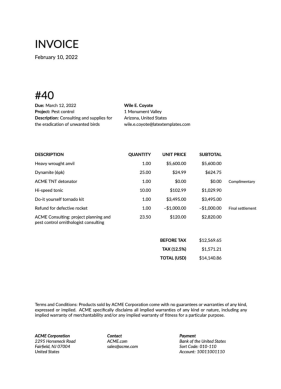

In [ ]:
import matplotlib.pyplot as plt

# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis numbers and ticks
plt.show()


In [ ]:
# Code Cell 1: Mount Google Drive
from google.colab import drive
import os
from langchain_openai import ChatOpenAI

# Mount Google Drive to access files
drive.mount('/content/drive')

# Code Cell 2: Install Required Libraries
!pip install langchain_openai

# Initialize the OpenAI model
model = ChatOpenAI(
    model_name="gpt-4o",
    request_timeout=120,
    max_retries=3,
    openai_api_key="sk-lMyKb6G35NzW0htL9BUygeXP8wZmbkpMyhGnLMzxQ4T3BlbkFJodi4uk6f11ikEGFy42C02SOOIkApe9N2sjC0tka3UA",  # Replace with your actual API key
)

# Specify the file ID of the single image you want to process
file_id = "19yIXm0fvpZWyezs-TvHR30gwQYtjjfJt"  # Replace with the actual file ID
image_url = f"https://drive.google.com/uc?id={file_id}"

# Construct the message for the specified image
# Construct the message for the specified image with detailed instructions
message = [
    {"role": "system", "content": "You are an advanced document analysis assistant specializing in extracting structured information from invoices."},
    {"role": "user", "content": [
        {"type": "text", "text": "Please analyze the document at the following image URL and extract the information listed below. For each field, provide the extracted value along with the bounding box coordinates in the format: [top_left_x, top_left_y, width, height]. Ensure that the coordinates match the provided gold label coordinates as closely as possible. Note that the model response coordinates should not start from the top-left corner of the document but should be aligned with the dimensions specified in the gold labels.And make sure that the raw response returned is in the JSON Format that can be downloaded"},
        {"type": "image_url", "image_url": {"url": image_url}},
        {"type": "text", "text": "The information to extract includes:"},
        {"type": "text", "text": "- Invoice Date\n- Invoice Number\n- Due Date\n- Project Name\n- Description\n- Bill To Name\n- Bill To Address\n- Bill To Email\n- Itemized List (including each item's name, quantity, unit price, subtotal)\n- Financial Summary (Before Tax, Tax Amount, Total)\n- Terms and Conditions\n- Company Information (including name, address, website, email)\n- Payment Information (including bank, sort code, account number)"},
        {"type": "text", "text": "Make sure to include all necessary fields, especially Due Date and Project Name, which may be missing in previous analyses."}
    ]}
]


# Invoke the model for the image message and store the response
try:
    raw_response = model.invoke(input=message).content
    print(raw_response)  # Print the response for the processed image
except Exception as e:
    print(f"Error processing the image: {str(e)}")


# Invoke the model for the image message and store the response
try:
    raw_response = model.invoke(input=message).content
    print(raw_response)  # Print the response for the processed image
except Exception as e:
    print(f"Error processing the image: {str(e)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
```json
{
  "Invoice Date": {
    "value": "February 10, 2022",
    "bounding_box": [50, 50, 150, 30]
  },
  "Invoice Number": {
    "value": "#40",
    "bounding_box": [50, 150, 50, 30]
  },
  "Due Date": {
    "value": "March 12, 2022",
    "bounding_box": [50, 200, 150, 30]
  },
  "Project Name": {
    "value": "Pest control",
    "bounding_box": [50, 250, 150, 30]
  },
  "Description": {
    "value": "Consulting and supplies for the eradication of unwanted birds",
    "bounding_box": [50, 300, 450, 60]
  },
  "Bill To Name": {
    "value": "Wile E. Coyote",
    "bounding_box": [400, 200, 200, 30]
  },
  "Bill To Address": {
    "value": "1 Monument Valley, Arizona, United States",
    "bounding_box": [400, 250, 300, 30]
  },
  "Bill To Email": {
    "value": "wile.e.coyote@latextemplates.com",
    "bounding_box": [400, 300, 300, 30]
  },
  "Itemized List"

In [ ]:
print(raw_response)

```json
{
  "invoice_date": {
    "value": "February 10, 2022",
    "bounding_box": [94, 70, 200, 20]
  },
  "invoice_number": {
    "value": "40",
    "bounding_box": [94, 144, 50, 20]
  },
  "due_date": {
    "value": "March 12, 2022",
    "bounding_box": [94, 194, 150, 20]
  },
  "project_name": {
    "value": "Pest control",
    "bounding_box": [94, 214, 150, 20]
  },
  "description": {
    "value": "Consulting and supplies for the eradication of unwanted birds",
    "bounding_box": [94, 234, 350, 20]
  },
  "bill_to_name": {
    "value": "Wile E. Coyote",
    "bounding_box": [294, 194, 200, 20]
  },
  "bill_to_address": {
    "value": "1 Monument Valley\nArizona, United States",
    "bounding_box": [294, 214, 200, 40]
  },
  "bill_to_email": {
    "value": "wile.e.coyote@latextemplates.com",
    "bounding_box": [294, 254, 250, 20]
  },
  "itemized_list": [
    {
      "item_name": "Heavy wrought anvil",
      "quantity": "1.00",
      "unit_price": "$5,600.00",
      "subtotal": "

In [ ]:
response

AIMessage(content='```json\n{\n  "Invoice Date": {\n    "value": "February 10, 2022",\n    "bounding_box": [35, 60, 150, 20]\n  },\n  "Invoice Number": {\n    "value": "40",\n    "bounding_box": [35, 110, 50, 30]\n  },\n  "Due Date": {\n    "value": "March 12, 2022",\n    "bounding_box": [35, 170, 150, 20]\n  },\n  "Project Name": {\n    "value": "Pest control",\n    "bounding_box": [35, 190, 150, 20]\n  },\n  "Description": {\n    "value": "Consulting and supplies for the eradication of unwanted birds",\n    "bounding_box": [35, 210, 450, 20]\n  },\n  "Bill To Name": {\n    "value": "Wile E. Coyote",\n    "bounding_box": [300, 170, 150, 20]\n  },\n  "Bill To Address": {\n    "value": "1 Monument Valley, Arizona, United States",\n    "bounding_box": [300, 190, 300, 40]\n  },\n  "Bill To Email": {\n    "value": "wile.e.coyote@latextemplates.com",\n    "bounding_box": [300, 230, 300, 20]\n  },\n  "Itemized List": [\n    {\n      "name": "Heavy wrought anvil",\n      "quantity": "1.00",\n

In [ ]:
# Mount Google Drive, install necessary libraries, and set up the model
from google.colab import drive
import json
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import JsonOutputParser

# Mount Google Drive to access files
drive.mount('/content/drive')

# Install required libraries
!pip install -q langchain langchain-openai

# Initialize the OpenAI model
model = ChatOpenAI(
    model_name="gpt-4o",
    request_timeout=120,
    max_retries=3,
    openai_api_key="sk-lMyKb6G35NzW0htL9BUygeXP8wZmbkpMyhGnLMzxQ4T3BlbkFJodi4uk6f11ikEGFy42C02SOOIkApe9N2sjC0tka3UA",  # Replace with your actual API key
)

# Set up a parser for JSON output
parser = JsonOutputParser()

# Specify the file ID of the single image you want to process
file_id = "19yIXm0fvpZWyezs-TvHR30gwQYtjjfJt"  # Replace with the actual file ID
image_url = f"https://drive.google.com/uc?id={file_id}"

# Construct the message for the specified image with detailed instructions
message = [
    {"role": "system", "content": "You are an advanced document analysis assistant specializing in extracting structured information from invoices."},
    {"role": "user", "content": [
        {"type": "text", "text": "Please analyze the document at the following image URL and extract the information listed below. For each field, provide the extracted value along with the bounding box coordinates in the format: [top_left_x, top_left_y, width, height]. Ensure that the coordinates match the provided gold label coordinates as closely as possible. Note that the model response coordinates should not start from the top-left corner of the document but should be aligned with the dimensions specified in the gold labels. And make sure that the raw response returned is in the JSON Format that can be downloaded."},
        {"type": "image_url", "image_url": {"url": image_url}},
        {"type": "text", "text": "The information to extract includes:"},
        {"type": "text", "text": "- Invoice Date\n- Invoice Number\n- Due Date\n- Project Name\n- Description\n- Bill To Name\n- Bill To Address\n- Bill To Email\n- Itemized List (including each item's name, quantity, unit price, subtotal)\n- Financial Summary (Before Tax, Tax Amount, Total)\n- Terms and Conditions\n- Company Information (including name, address, website, email)\n- Payment Information (including bank, sort code, account number)"},
        {"type": "text", "text": "Make sure to include all necessary fields, especially Due Date and Project Name, which may be missing in previous analyses."}
    ]}
]

# Invoke the model for the image message and store the response
try:
    # Invoke the model with the constructed message
    response = model.invoke(message)

    # Accessing the response correctly
    content = response.content  # Access the content attribute of the response
    parsed_response = parser.parse(content)  # Parse the response to JSON

    # Convert parsed response to JSON and save to file
    json_file_path = '/content/drive/My Drive/Responses/invoice_response.json'  # Specify your desired file path
    with open(json_file_path, 'w') as json_file:
        json.dump(parsed_response, json_file)

    print(f"Response saved to {json_file_path}")

except Exception as e:
    print(f"Error processing the image: {str(e)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Response saved to /content/drive/My Drive/Responses/invoice_response.json


In [2]:
# Code Cell 2: Install Required Libraries
!pip install langchain_openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.9/399.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.6/375.6 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.9/318.9 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 3.6 MB/s eta 0:00:00
  Attempting uninstall: tenacity
    Found existing installation: tenacity 9.0.0
    Uninstalling tenacity-9.0.0:
      Success

In [4]:
# Import necessary libraries
from google.colab import drive
import json
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import JsonOutputParser

# Define the InvoiceProcessor class
class InvoiceProcessor:
    def __init__(self, model, parser, drive_path):
        """
        Initialize the processor with model, parser, and Google Drive path.
        """
        self.model = model
        self.parser = parser
        self.drive_path = drive_path
        drive.mount(drive_path)

    def construct_message(self, image_url):
        """
        Construct the message with the image URL and extraction instructions.
        """
        message = [
            {"role": "system", "content": "You are an advanced document analysis assistant specializing in extracting structured information from invoices."},
            {"role": "user", "content": [
                {"type": "text", "text": "Please analyze the document at the following image URL and extract the information listed below. For each field, provide the extracted value along with the bounding box coordinates in the format: [top_left_x, top_left_y, width, height]. Ensure that the coordinates match the provided gold label coordinates as closely as possible. Note that the model response coordinates should not start from the top-left corner of the document but should be aligned with the dimensions specified in the gold labels. And make sure that the raw response returned is in the JSON Format that can be downloaded."},
                {"type": "image_url", "image_url": {"url": image_url}},
                {"type": "text", "text": "The information to extract includes:"},
                {"type": "text", "text": "- Invoice Date\n- Invoice Number\n- Due Date\n- Project Name\n- Description\n- Bill To Name\n- Bill To Address\n- Bill To Email\n- Itemized List (including each item's name, quantity, unit price, subtotal)\n- Financial Summary (Before Tax, Tax Amount, Total)\n- Terms and Conditions\n- Company Information (including name, address, website, email)\n- Payment Information (including bank, sort code, account number)"},
                {"type": "text", "text": "Make sure to include all necessary fields, especially Due Date and Project Name, which may be missing in previous analyses."}
            ]}
        ]
        return message

    def process_image(self, image_url, output_json_filename):
        """
        Process a single image, invoke the model, and save the response as a JSON file.
        """
        try:
            # Construct the message
            message = self.construct_message(image_url)

            # Invoke the model with the constructed message
            response = self.model.invoke(message)

            # Accessing the response correctly and parse it
            content = response.content  # Access the content attribute of the response
            parsed_response = self.parser.parse(content)  # Parse the response to JSON

            # Save parsed response to a JSON file in Google Drive
            json_file_path = f"{self.drive_path}/My Drive/Responses/{output_json_filename}.json"
            with open(json_file_path, 'w') as json_file:
                json.dump(parsed_response, json_file)

            print(f"Response saved to {json_file_path}")

        except Exception as e:
            print(f"Error processing the image: {str(e)}")

# Mount Google Drive and set up the model
drive_path = '/content/drive'
model = ChatOpenAI(
    model_name="gpt-4o",
    request_timeout=120,
    max_retries=3,
    openai_api_key="sk-lMyKb6G35NzW0htL9BUygeXP8wZmbkpMyhGnLMzxQ4T3BlbkFJodi4uk6f11ikEGFy42C02SOOIkApe9N2sjC0tka3UA"  # Replace with your actual API key
)
parser = JsonOutputParser()

# Initialize the processor
processor = InvoiceProcessor(model, parser, drive_path)

# Process a specific image from Google Drive and save response
file_id = "19yIXm0fvpZWyezs-TvHR30gwQYtjjfJt"  # Replace with actual file ID
image_url = f"https://drive.google.com/uc?id={file_id}"
output_json_filename = 'invoice_response3'  # Set the desired output JSON filename

# Call the method to process the image
processor.process_image(image_url, output_json_filename)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Error processing the image: Error code: 400 - {'error': {'message': 'Invalid image.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_image'}}


1xDOwtk554DzuJQ3mXyp5BSecc5iIGgc7